In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux


import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



In [2]:
import stableemrifisher
stableemrifisher.__file__

'/nfs/home/svu/e1498138/localgit/Fisher/StableEMRIFisher/stableemrifisher/__init__.py'

In [3]:
from tqdm import tqdm
from stableemrifisher.fisher.fisher import StableEMRIFisher
from stableemrifisher.utils import inner_product

startup


In [4]:
# GPU configuration
use_gpu = True
dt = 10     # Time step
T = 2   # Total time

In [5]:
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
        "err": 1e-15  # Error tolerance 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True
}

In [6]:
gwf = GWfuncs.GravWaveAnalysis(T, dt)

In [7]:
waveform_class = FastKerrEccentricEquatorialFlux
waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                             amplitude_kwargs=amplitude_kwargs,
                             Ylm_kwargs=Ylm_kwargs,
                             sum_kwargs=sum_kwargs,
                             use_gpu=use_gpu)

 
#waveform generator setup
waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(frame='detector')

In [8]:
gew_waveform_gen = GenerateEMRIWaveform(
    waveform_class, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

In [37]:
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 #11.7 if u want to plunge, original = 15
e0 = 0.4
xI0 = 1.0
dist = 0.9 # Gpc
qS = 0.5
phiS = 1.0
qK =  2.67 #ori : 1.0
phiK = phiS + np.pi/3
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5




In [38]:
from lisatools.sensitivity import get_sensitivity, CornishLISASens
sef = StableEMRIFisher(
    waveform_class=waveform_class,
    waveform_class_kwargs=waveform_class_kwargs,
    waveform_generator=waveform_generator,
    waveform_generator_kwargs=waveform_generator_kwargs,
    stats_for_nerds=True,
    use_gpu=use_gpu,
    deriv_type='stable',
    noise_model=get_sensitivity,
    noise_kwargs={'sens_fn': CornishLISASens, 'return_type': 'PSD'},
    channels=["A"]
)

# Fisher calculation parameters
der_order = 4
Ndelta = 8
stability_plot = False
param_names = ['m1', 'm2', 'a', 'p0', 'e0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


In [39]:
Fisher = sef(*pars_list, param_names = param_names, 
             T = T, dt = dt, 
             der_order = der_order, 
             Ndelta = Ndelta, 
             stability_plot = stability_plot,
            #  delta_range = delta_range,
            live_dangerously = False)

T:  2 dt:  10
Body is not plunging, Fisher should be stable.


wave ndim: 2
Computing SNR for parameters: (1000000.0, 30.0, 0.7, 11.7, 0.4, 1.0, 0.9, 0.5, 1.0, 2.67, 2.0471975511965974, 0.4, 0.0, 0.5)
Waveform Generated. SNR: 72.31498926580151
calculating stable deltas...
Gamma_ii for m1: 24442.463340619783
Gamma_ii for m1: 24442.463340966795
Gamma_ii for m1: 24442.463341198756
Gamma_ii for m1: 24442.46334350282
Gamma_ii for m1: 24442.463324496348
Gamma_ii for m1: 24442.46326582796
Gamma_ii for m1: 24442.462796882166
Gamma_ii for m1: 24442.468320256223
[1.4197106144847528e-11, 9.4900895822556e-12, 9.426476019982218e-11, 7.776004761955065e-10, 2.400265000440225e-09, 1.918570140476164e-08, 2.2597447951749737e-07]
1
Gamma_ii for m2: 2636559897688.311
Gamma_ii for m2: 2636559897680.9224
Gamma_ii for m2: 2636559897487.1025
Gamma_ii for m2: 2636559893631.727
Gamma_ii for m2: 2636559896528.5205
Gamma_ii for m2: 2636559884769.5386
Gamma_ii for m2: 2636559503977.84
Gamma_ii for m2: 2636558708426.623
[2.802391055670293e-12, 7.3512391811572e-11, 1.4622749506

In [40]:
Fisher.shape

(5, 5)

In [41]:
# CHAIN RULE FOR FISHER
J_mx = np.eye(5)
J_mx[0, 0] = m1
J_mx[1, 1] = m2

Fisher_scaled = J_mx.T @ Fisher @ J_mx

(<Figure size 2000x2000 with 15 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

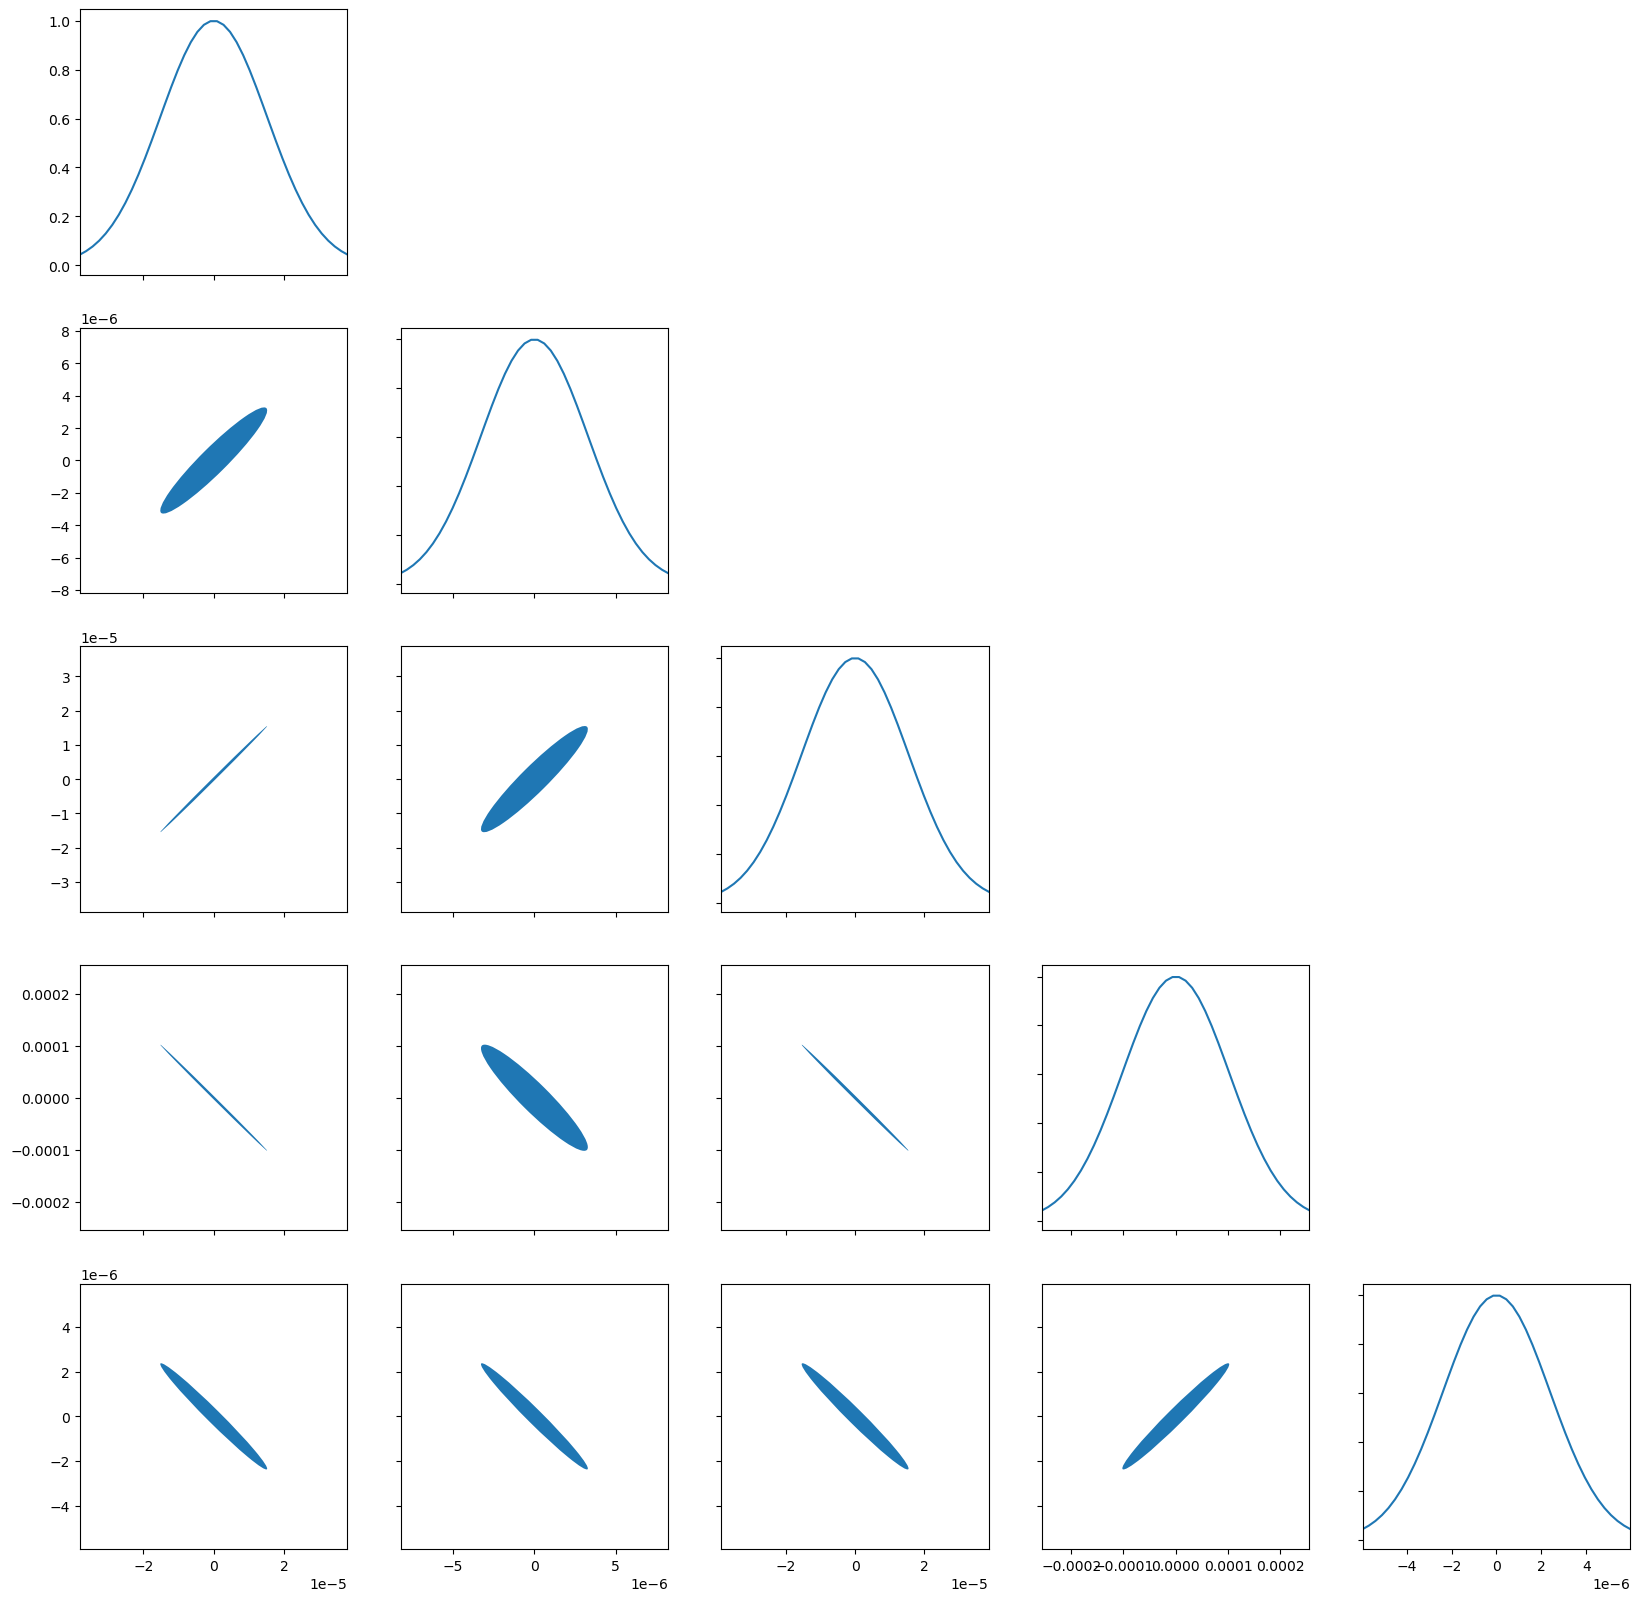

In [42]:
from stableemrifisher.plot import CovEllipsePlot

CovEllipsePlot(np.linalg.inv(Fisher_scaled))

In [43]:
cov = np.linalg.inv(Fisher_scaled)
cov

array([[ 2.31580247e-10,  4.69970590e-11,  2.35779243e-10,
        -1.55466065e-09, -3.56263565e-11],
       [ 4.69970590e-11,  1.07629621e-11,  4.78025481e-11,
        -3.12008043e-10, -7.65587462e-12],
       [ 2.35779243e-10,  4.78025481e-11,  2.40376286e-10,
        -1.58351155e-09, -3.61659335e-11],
       [-1.55466065e-09, -3.12008043e-10, -1.58351155e-09,
         1.04477253e-08,  2.37796803e-10],
       [-3.56263565e-11, -7.65587462e-12, -3.61659335e-11,
         2.37796803e-10,  5.65787135e-12]])

In [44]:
import pickle
with open('cov_matrix_snr72.pkl', 'wb') as f:
    pickle.dump(cov, f)

# Check Waveform

In [31]:
params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


In [32]:
h = gew_waveform_gen(*params, T=T, dt=dt)


In [33]:
gwf.rhostat(h)

array(72.31498927)

In [34]:
h_short = gew_waveform_gen(*params, T=1/12, dt=dt)


In [35]:
gwf_short = GWfuncs.GravWaveAnalysis(T=1/12,dt=10)

In [36]:
gwf_short.rhostat(h_short)

array(5.24476011)